In [2]:
import numpy as np
import pandas as pd

In [5]:
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

In [6]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [7]:
test_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

Train shape: (1296675, 12)
Test shape: (555719, 12)

Missing values in train (top 10):


category             0
amt                  0
gender               0
state                0
city_pop             0
unix_time            0
is_fraud             0
transaction_hour     0
transaction_day      0
transaction_month    0
dtype: int64


Target distribution:


is_fraud
Legit    1289169
Fraud       7506
Name: count, dtype: int64

/var/folders/cs/2kt6y4jj005czs934w3jmmg40000gn/T/ipykernel_62942/944846478.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_clean, x="is_fraud", palette="Set2", ax=axes[0])
/var/folders/cs/2kt6y4jj005czs934w3jmmg40000gn/T/ipykernel_62942/944846478.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_rate.values, y=category_rate.index, palette="crest", ax=axes[1])


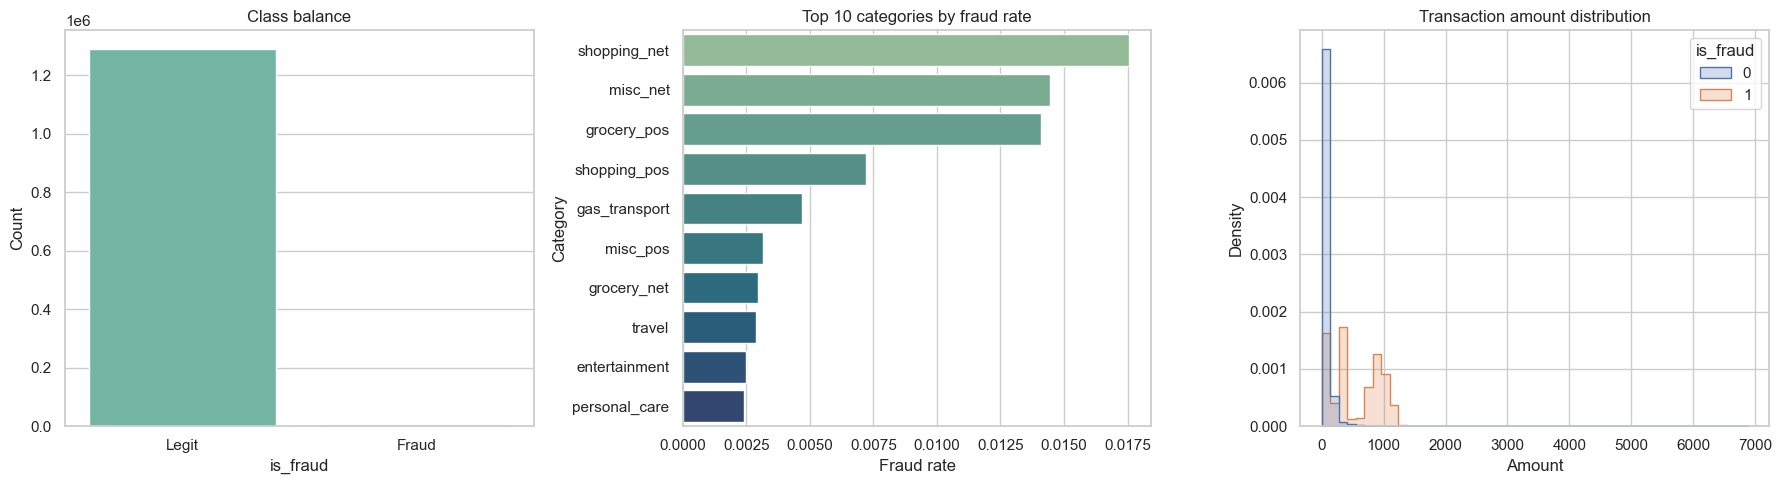


Model evaluation on fraudTest.csv
              precision    recall  f1-score   support

           0     0.9986    0.9999    0.9992    553574
           1     0.9700    0.6322    0.7655      2145

    accuracy                         0.9985    555719
   macro avg     0.9843    0.8160    0.8824    555719
weighted avg     0.9985    0.9985    0.9983    555719

ROC AUC: 0.9843
Average precision: 0.8546


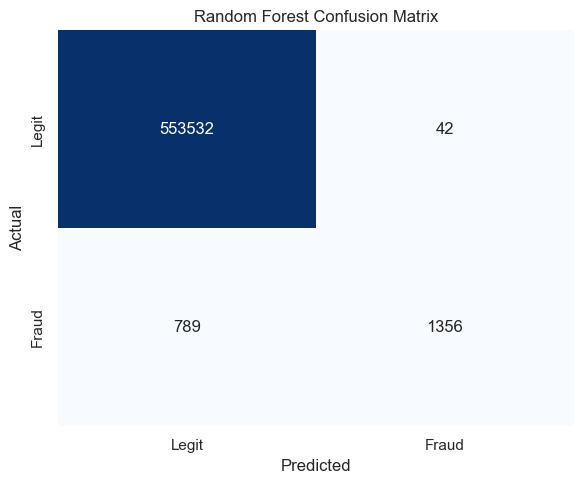

/var/folders/cs/2kt6y4jj005czs934w3jmmg40000gn/T/ipykernel_62942/944846478.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="mako")


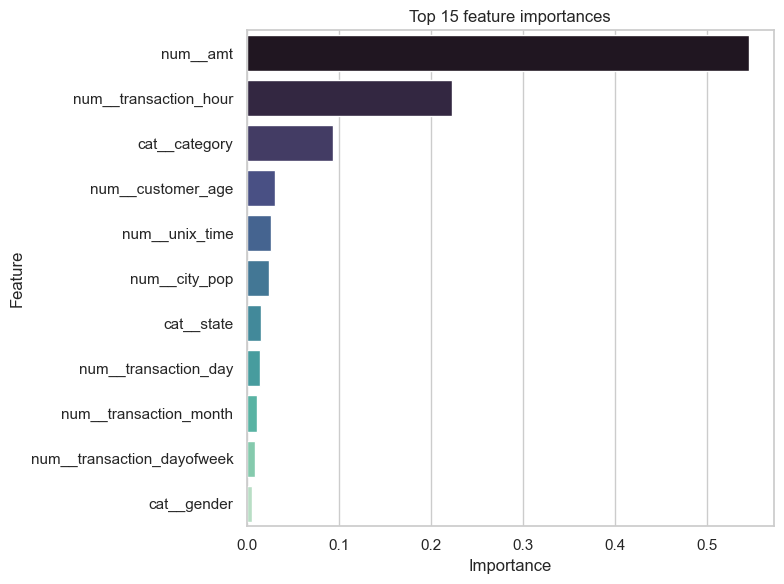

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)


def engineer_features(frame):
    data = frame.copy()
    data.columns = data.columns.str.strip()

    data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"], errors="coerce")
    data["dob"] = pd.to_datetime(data["dob"], errors="coerce")

    data["transaction_hour"] = data["trans_date_trans_time"].dt.hour
    data["transaction_day"] = data["trans_date_trans_time"].dt.day
    data["transaction_month"] = data["trans_date_trans_time"].dt.month
    data["transaction_dayofweek"] = data["trans_date_trans_time"].dt.dayofweek

    age = data["trans_date_trans_time"].dt.year - data["dob"].dt.year
    birthday_not_passed = (
        (data["trans_date_trans_time"].dt.month < data["dob"].dt.month)
        | (
            (data["trans_date_trans_time"].dt.month == data["dob"].dt.month)
            & (data["trans_date_trans_time"].dt.day < data["dob"].dt.day)
        )
    )
    data["customer_age"] = age - birthday_not_passed.fillna(False).astype(int)

    drop_columns = [
        "Unnamed: 0",
        "trans_date_trans_time",
        "dob",
        "trans_num",
        "first",
        "last",
        "street",
        "city",
        "zip",
        "lat",
        "long",
        "merch_lat",
        "merch_long",
        "cc_num",
        "merchant",
        "job",
    ]
    data = data.drop(columns=[column for column in drop_columns if column in data.columns])
    return data


train_clean = engineer_features(train_df)
test_clean = engineer_features(test_df)

print("Train shape:", train_clean.shape)
print("Test shape:", test_clean.shape)
print("\nMissing values in train (top 10):")
display(train_clean.isna().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
display(train_clean["is_fraud"].value_counts().rename(index={0: "Legit", 1: "Fraud"}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=train_clean, x="is_fraud", palette="Set2", ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_xlabel("is_fraud")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Legit", "Fraud"])

category_rate = (
    train_clean.groupby("category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
sns.barplot(x=category_rate.values, y=category_rate.index, palette="crest", ax=axes[1])
axes[1].set_title("Top 10 categories by fraud rate")
axes[1].set_xlabel("Fraud rate")
axes[1].set_ylabel("Category")

eda_sample = train_clean.sample(n=min(50000, len(train_clean)), random_state=42)
sns.histplot(
    data=eda_sample,
    x="amt",
    hue="is_fraud",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[2],
)
axes[2].set_title("Transaction amount distribution")
axes[2].set_xlabel("Amount")
axes[2].set_ylabel("Density")

plt.tight_layout()
plt.show()

X_train = train_clean.drop(columns="is_fraud")
y_train = train_clean["is_fraud"]
X_test = test_clean.drop(columns="is_fraud")
y_test = test_clean["is_fraud"]

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                    ),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

model = RandomForestClassifier(
    n_estimators=80,
    max_depth=18,
    max_samples=0.2,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample",
)

clf = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)
probabilities = clf.predict_proba(X_test)[:, 1]

print("\nModel evaluation on fraudTest.csv")
print(classification_report(y_test, predictions, digits=4))
print(f"ROC AUC: {roc_auc_score(y_test, probabilities):.4f}")
print(f"Average precision: {average_precision_score(y_test, probabilities):.4f}")

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Legit", "Fraud"],
    yticklabels=["Legit", "Fraud"],
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
feature_importance = pd.Series(
    clf.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="mako")
plt.title("Top 15 feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [2]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.6/556.6 kB 9.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 10.8 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]4/6 [numba]te]
Note: you may need to restart the kernel to use updated packages.


In [2]:
from generate_explainability_dataset import generate_explainability_dataset

generate_explainability_dataset(
    train_path="fraudTrain.csv",
    test_path="fraudTest.csv",
    output_path="fraudTest_explainability_10000.csv",
    chunk_size=2000,
    max_test_rows=10000,
    random_state=42,
)

Processed 2000/10000 rows
Processed 4000/10000 rows
Processed 6000/10000 rows
Processed 8000/10000 rows
Processed 10000/10000 rows
Explainability dataset saved to: fraudTest_explainability_10000.csv


In [3]:
from create_powerbi_ready_dataset import build_powerbi_ready_dataset

build_powerbi_ready_dataset(
    source_file="fraudTest_explainability_10000.csv",
    output_file="PowerBI_Ready_FraudData.csv",
)

Saved Power BI-ready dataset to: PowerBI_Ready_FraudData.csv
Rows written: 30000


In [4]:
import pandas as pd

powerbi = pd.read_csv("PowerBI_Ready_FraudData.csv")
fraud = pd.read_csv("fraudTest_explainability_10000.csv")

merged = powerbi.merge(
    fraud[
        [
            "Unnamed: 0",
            "city",
            "state",
            "zip",
            "lat",
            "long",
            "merch_lat",
            "merch_long",
        ]
    ],
    on="Unnamed: 0",
    how="left"
)

merged.to_csv("PowerBI_Dashboard_Final.csv", index=False)

print(merged.shape)
print("Saved: PowerBI_Dashboard_Final.csv")

(30000, 18)
Saved: PowerBI_Dashboard_Final.csv
